#### Plan
1. Import libraries and sample of dataset
2. Conduct Exploratory Data Analysis (EDA)
    - Indentify anomalies with box and distribution plots
    - Identify missing values, outliers and unique records
    - Count categorical features
3. Clean dataset, add extra columns to conduct quick analysis in Excel
4. Export data as csv file

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
# read csv file
df = pd.read_csv('taxi_dataset.csv')

# helper columns 
df["trip_minutes"] = round(df["trip_seconds"] / 60, 2)
df["fare_per_mile"] = round(df["fare"] / df["trip_miles"], 2)
df.head(5)

,unique_key,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,payment_type,company,pickup_latitude,pickup_longitude,pickup_location,dropoff_latitude,dropoff_longitude,dropoff_location,trip_minutes,fare_per_mile
0,e2afbb4f62fb3865c4d928a39e8a4d1e711ea8da,5cee8ec7dd48dd171270a4f56ac537aa955fb0404ea5ad...,2017-11-03 11:45:00 UTC,2017-11-03 11:45:00 UTC,365.0,2.3,NaN,NaN,NaN,NaN,...,Cash,Metro Group,NaN,NaN,NaN,NaN,NaN,NaN,6.08,3.13
1,a663e8249660b7a3ae13c9a39378ff495564e8e6,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 20:30:00 UTC,2016-10-28 20:30:00 UTC,192.0,1.4,NaN,NaN,NaN,NaN,...,Cash,303 Taxi,NaN,NaN,NaN,NaN,NaN,NaN,3.20,4.00
2,a99a7309aea3cf70eed1644c254eb30b150ac4f2,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 20:45:00 UTC,2016-10-28 20:45:00 UTC,328.0,2.1,NaN,NaN,NaN,NaN,...,Cash,303 Taxi,NaN,NaN,NaN,NaN,NaN,NaN,5.47,3.62
3,ad0d9e702d67b0e9e7b85dd0750605ff06389c4f,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 21:45:00 UTC,2016-10-28 22:00:00 UTC,706.0,7.6,NaN,NaN,NaN,NaN,...,Cash,303 Taxi,NaN,NaN,NaN,NaN,NaN,NaN,11.77,2.68
4,350b48036f17d07f79abf53d04b811da8b6c264c,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-29 09:45:00 UTC,2016-10-29 10:30:00 UTC,3407.0,50.7,NaN,NaN,NaN,NaN,...,Cash,303 Taxi,NaN,NaN,NaN,NaN,NaN,NaN,56.78,0.00


### EDA

#### Helper funcitons

In [127]:
# General col info
def columns_info(df, cols, zero=False):
    df_len = df.shape[0]
    summary = []

    # loop through the columns and calculate missing values, unique values, and zero values (if specified)
    for col in cols:
        missing = df[col].isnull().sum()
        missing_pct = round(missing / df_len * 100, 2)
        unique = df[col].nunique()

        if zero:
            zero_values = df[col].apply(lambda x: x == 0).sum()
            zero_pct = round(zero_values / df_len * 100, 2)
            summary.append({"column": col, "missing": missing, "missing_pct": missing_pct, "unique": unique, "zero's_pct": zero_pct})
        else:
            summary.append({"column": col, "missing": missing, "missing_pct": missing_pct, "unique": unique})

    return pd.DataFrame(summary)

# Numerical distribution plots
def numerical_distribution(df, cols):
    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Histogram
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"Histogram of {col}")
        axes[0].set_xlabel(col)

        # Boxplot
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"Boxplot of {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()


# Categorical distribution plots
def categorical_distribution(df, cols):
    for col in cols:
        if col == "company":
            plt.figure(figsize=(10, 10))
        else:
            plt.figure(figsize=(10, 6))

        order = df[col].value_counts().index
        ax = sns.countplot(data=df, y=col, order=order)
        for container in ax.containers:
            ax.bar_label(container, padding=3)

        plt.title(f"Distribution of {col}")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

#### Numerical values

In [128]:
numerical_cols = [ "trip_miles", "trip_minutes", "fare", "fare_per_mile" ]

# Numerical value distribution
df[numerical_cols].describe().round(3).T

/home/bars1k/taxi_data/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
trip_miles,199989.0,5.543,7.625,0.0,1.30,2.50,7.00,388.10
trip_minutes,199957.0,16.957,35.864,0.0,7.00,12.00,20.00,1439.00
fare,199988.0,15.666,41.823,0.0,6.75,10.00,18.75,9211.59
fare_per_mile,199815.0,inf,NaN,0.0,2.71,3.82,5.40,inf


In [129]:
columns_info(df, numerical_cols, zero=True)

,column,missing,missing_pct,unique,zero's_pct
0,trip_miles,11,0.01,3487,6.34
1,trip_minutes,43,0.02,4564,1.70
2,fare,12,0.01,1507,0.09
3,fare_per_mile,185,0.09,2705,1.86


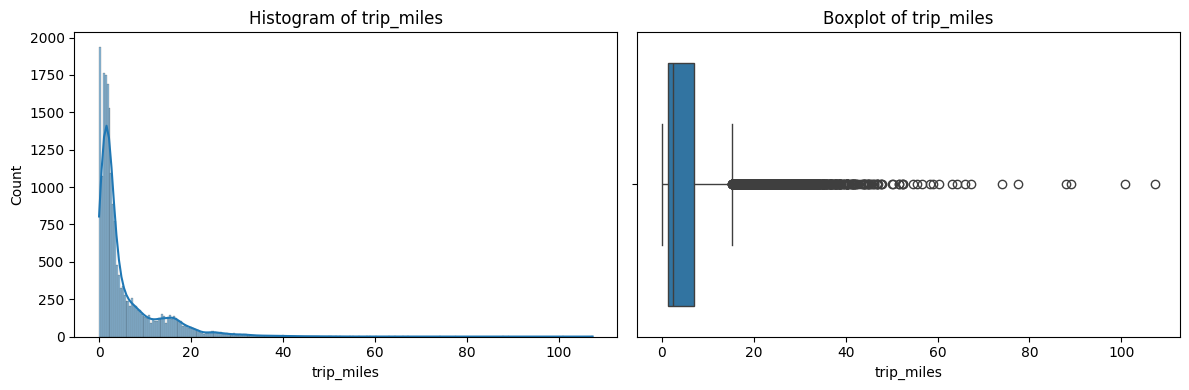

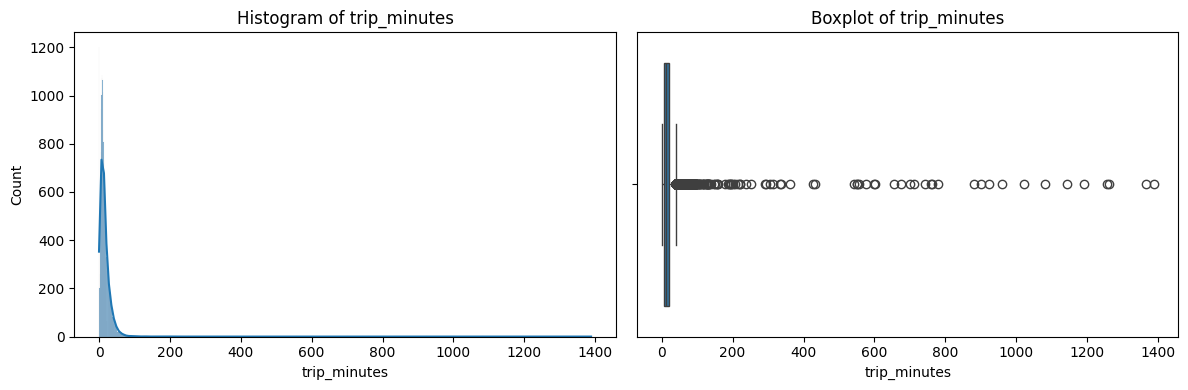

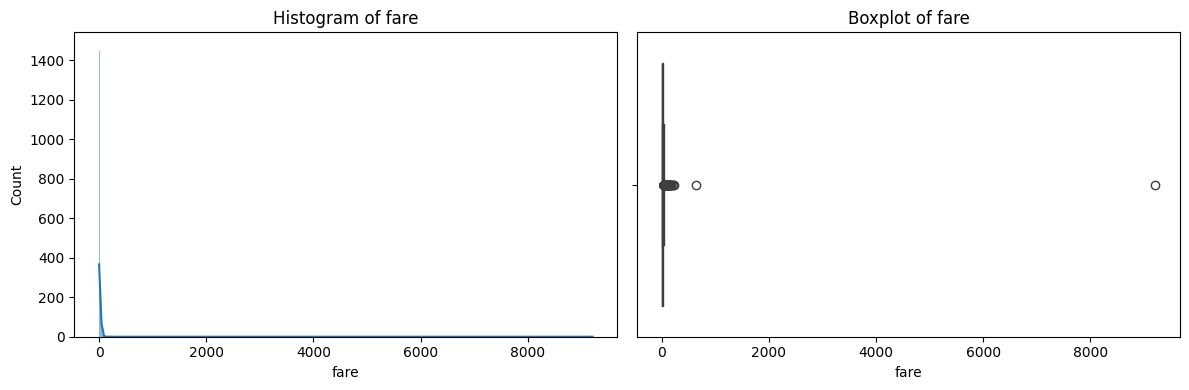

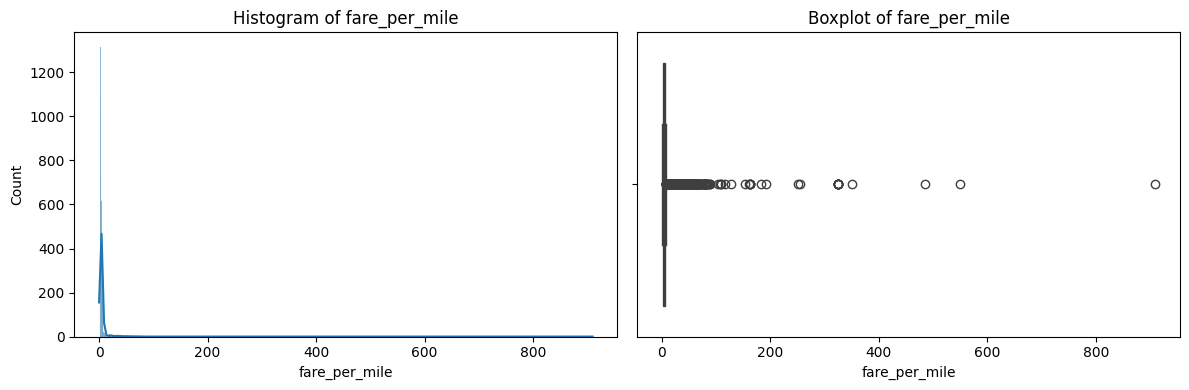

In [130]:
sample_df = df.sample(20000)
numerical_distribution(sample_df, numerical_cols)

#### Categorical values

In [131]:
# Create buckets for trip duration and distance distribution analysis

min_bins = [0, 5, 10, 20, 40, 60, float("inf")]
min_labels = ["0-5 min", "5-10 min", "10-20 min", "20-40 min", "40-60 min", "60+"]
df["duration_bucket"] = pd.cut(df["trip_minutes"], bins=min_bins, labels=min_labels, right=False)


mile_bins = [0, 1, 3, 5, 10, 20, float("inf")]
mile_labels = ["0-1 mile", "1-3 miles", "3-5 miles", "5-10 miles", "10-20 miles", "20+ miles"]
df["distance_bucket"] = pd.cut(df["trip_miles"], bins=mile_bins, labels=mile_labels, right=False)

# Select categorical columns
categorical_cols = ["duration_bucket", "distance_bucket", "payment_type", "company"]

columns_info(df, categorical_cols, zero=False)

,column,missing,missing_pct,unique
0,duration_bucket,43,0.02,6
1,distance_bucket,11,0.01,6
2,payment_type,0,0.00,6
3,company,93668,46.83,28


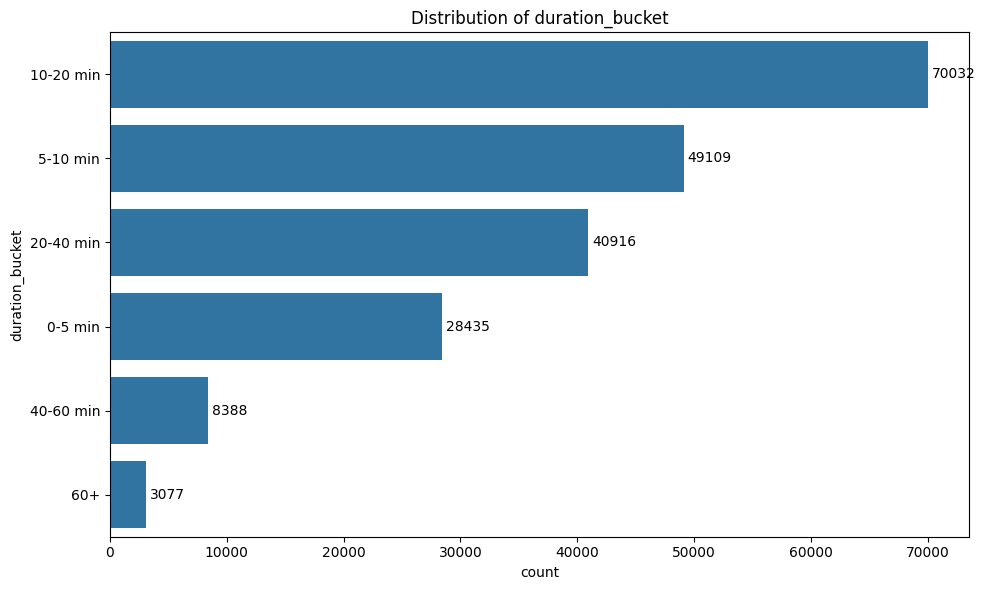

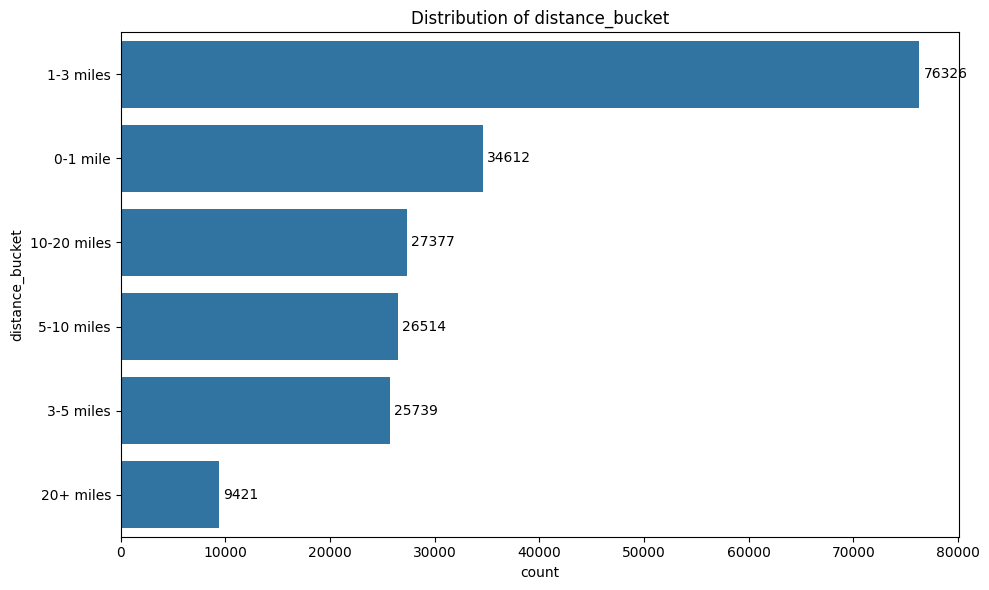

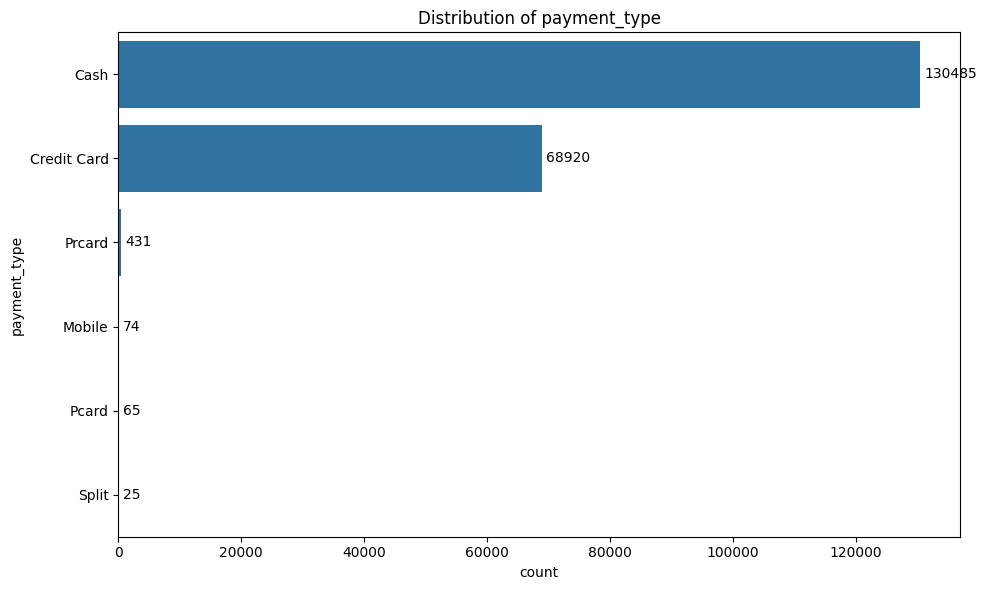

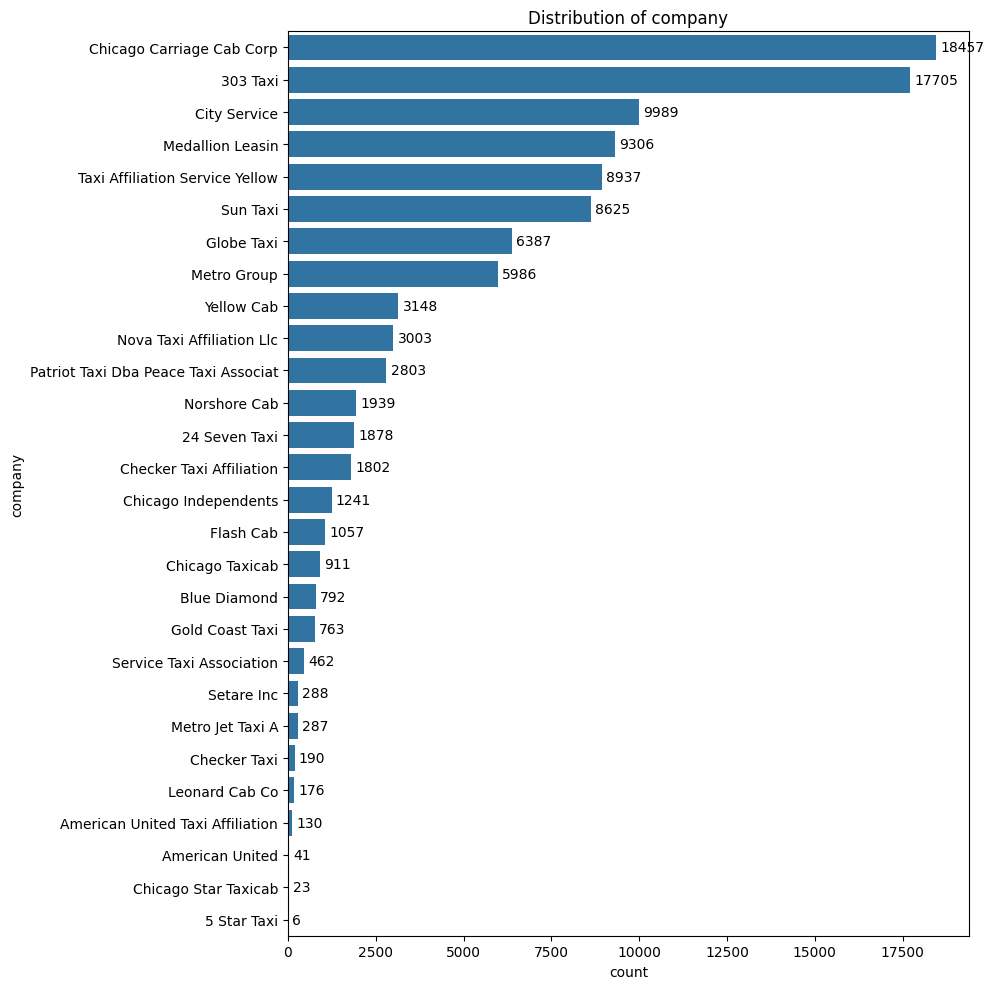

In [132]:
# Quick overview of categorical values distribution
categorical_distribution(df, categorical_cols)

### Data cleaning & Feature engineering

In [133]:
# Remove missing values
df = df.dropna(axis=0, subset=["trip_minutes", "trip_miles", "fare", "trip_total"])

# Remove outliers
outliers_mask = (df["trip_miles"] > 0) & (df["trip_miles"] < 200) & (df["fare_per_mile"] < 100) & (df["trip_minutes"] > 0) & (df["fare"] > 0)
df = df[outliers_mask]

# Remove unwanted columns
cols_to_remove = [
    "unique_key",
    "trip_seconds",
    "pickup_census_tract",
    "dropoff_census_tract",
    "pickup_longitude",
    "pickup_location",
    "dropoff_latitude",
    "dropoff_longitude",
    "dropoff_location",
    "fare_per_mile",
]

df = df.drop(columns=cols_to_remove)

In [134]:
# Replace trip id by int
df["trip_id"] = range(1, len(df) + 1)

# Date and time features
df["month_num"] = pd.to_datetime(df["trip_start_timestamp"]).dt.month
df["month_name"] = pd.to_datetime(df["trip_start_timestamp"]).dt.month_name()
df["weekday_num"] = pd.to_datetime(df["trip_start_timestamp"]).dt.weekday + 1
df["weekday_name"] = pd.to_datetime(df["trip_start_timestamp"]).dt.day_name()
df["hour"] = pd.to_datetime(df["trip_start_timestamp"]).dt.hour

# Working day flag
df["is_working_day"] = np.where(~df["weekday_num"].isin([6, 7]), 1, 0)

# Daytime buckets
hour_conditions = [(df["hour"] >= 5) & (df["hour"] < 12), (df["hour"] >= 12) & (df["hour"] < 17), (df["hour"] >= 17) & (df["hour"] < 21)]
choices = ["Morning", "Afternoon", "Evening"]
df["time_of_day"] = np.select(hour_conditions, choices, default="Night")

# Concatenated pickup and dropoff areas
mask = df["pickup_community_area"].notnull() & df["dropoff_community_area"].notnull()
df["pickup_dropoff"] = np.where(
    mask, df["pickup_community_area"].astype("Int64").astype(str) + " to " + df["dropoff_community_area"].astype("Int64").astype(str), np.nan
)

df.head(5)

,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,...,distance_bucket,trip_id,month_num,month_name,weekday_num,weekday_name,hour,is_working_day,time_of_day,pickup_dropoff
0,5cee8ec7dd48dd171270a4f56ac537aa955fb0404ea5ad...,2017-11-03 11:45:00 UTC,2017-11-03 11:45:00 UTC,2.3,NaN,NaN,7.20,0.0,NaN,0.0,...,1-3 miles,1,11,November,5,Friday,11,1,Morning,NaN
1,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 20:30:00 UTC,2016-10-28 20:30:00 UTC,1.4,NaN,NaN,5.60,0.0,NaN,0.0,...,1-3 miles,2,10,October,5,Friday,20,1,Evening,NaN
2,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 20:45:00 UTC,2016-10-28 20:45:00 UTC,2.1,NaN,NaN,7.60,0.0,NaN,0.0,...,1-3 miles,3,10,October,5,Friday,20,1,Evening,NaN
3,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-28 21:45:00 UTC,2016-10-28 22:00:00 UTC,7.6,NaN,NaN,20.40,0.0,NaN,2.0,...,5-10 miles,4,10,October,5,Friday,21,1,Night,NaN
4,f871ebb01073ef31155285c13e4cfeb91a9f89492e0cbd...,2016-10-29 09:45:00 UTC,2016-10-29 10:30:00 UTC,50.7,NaN,NaN,0.01,0.0,NaN,0.0,...,20+ miles,5,10,October,6,Saturday,9,0,Morning,NaN


#### Export data 

In [138]:
# Export csv file
df.to_csv("taxi_data.csv", index=False)